In [1]:
import torch
import glob
from pathlib import Path
from kappa import sweep_pairs_vectorized


max_prob_ratio = 100
grads_files = sorted(glob.glob("results/grads_*.pt"))

for f in grads_files:
    data = torch.load(f, weights_only=False)
    G, g_all = data["G"], data["g_all"]
    tokens = data["tokens"]
    token_info = data["token_info"]
    probs = torch.tensor([token_info[t]["prob"] for t in tokens])
    
    pairs = sweep_pairs_vectorized(tokens, probs, G, g_all, max_prob_ratio=max_prob_ratio)
    print(f"{Path(f).name}:  tokens={len(tokens)},  pairs={len(pairs)}")

grads_Qwen2.5-0.5B_L23_food_top100.pt:  tokens=87,  pairs=3687
grads_Qwen2.5-0.5B_L23_movie_top100.pt:  tokens=90,  pairs=4005
grads_Qwen2.5-0.5B_L23_weather_top100.pt:  tokens=89,  pairs=3916
grads_Qwen2.5-0.5B_Lall_food_top100.pt:  tokens=87,  pairs=3687
grads_Qwen2.5-0.5B_Lall_movie_top100.pt:  tokens=90,  pairs=4005
grads_Qwen2.5-0.5B_Lall_weather_top100.pt:  tokens=89,  pairs=3916
grads_Qwen2.5-1.5B_L27_food_top100.pt:  tokens=74,  pairs=2633
grads_Qwen2.5-1.5B_L27_movie_top100.pt:  tokens=88,  pairs=3828
grads_Qwen2.5-1.5B_L27_weather_top100.pt:  tokens=87,  pairs=3741
grads_Qwen2.5-3B_L35_food_top100.pt:  tokens=78,  pairs=2954
grads_Qwen2.5-3B_L35_movie_top100.pt:  tokens=91,  pairs=4095
grads_Qwen2.5-3B_L35_weather_top100.pt:  tokens=85,  pairs=3570


Qwen2.5-0.5B / food (L23): 87 tokens, 3687 pairs
Qwen2.5-0.5B / movie (L23): 90 tokens, 4005 pairs
Qwen2.5-0.5B / weather (L23): 89 tokens, 3916 pairs
Qwen2.5-1.5B / food (L27): 74 tokens, 2633 pairs
Qwen2.5-1.5B / movie (L27): 88 tokens, 3828 pairs
Qwen2.5-1.5B / weather (L27): 87 tokens, 3741 pairs
Qwen2.5-3B / food (L35): 78 tokens, 2954 pairs
Qwen2.5-3B / movie (L35): 91 tokens, 4095 pairs
Qwen2.5-3B / weather (L35): 85 tokens, 3570 pairs


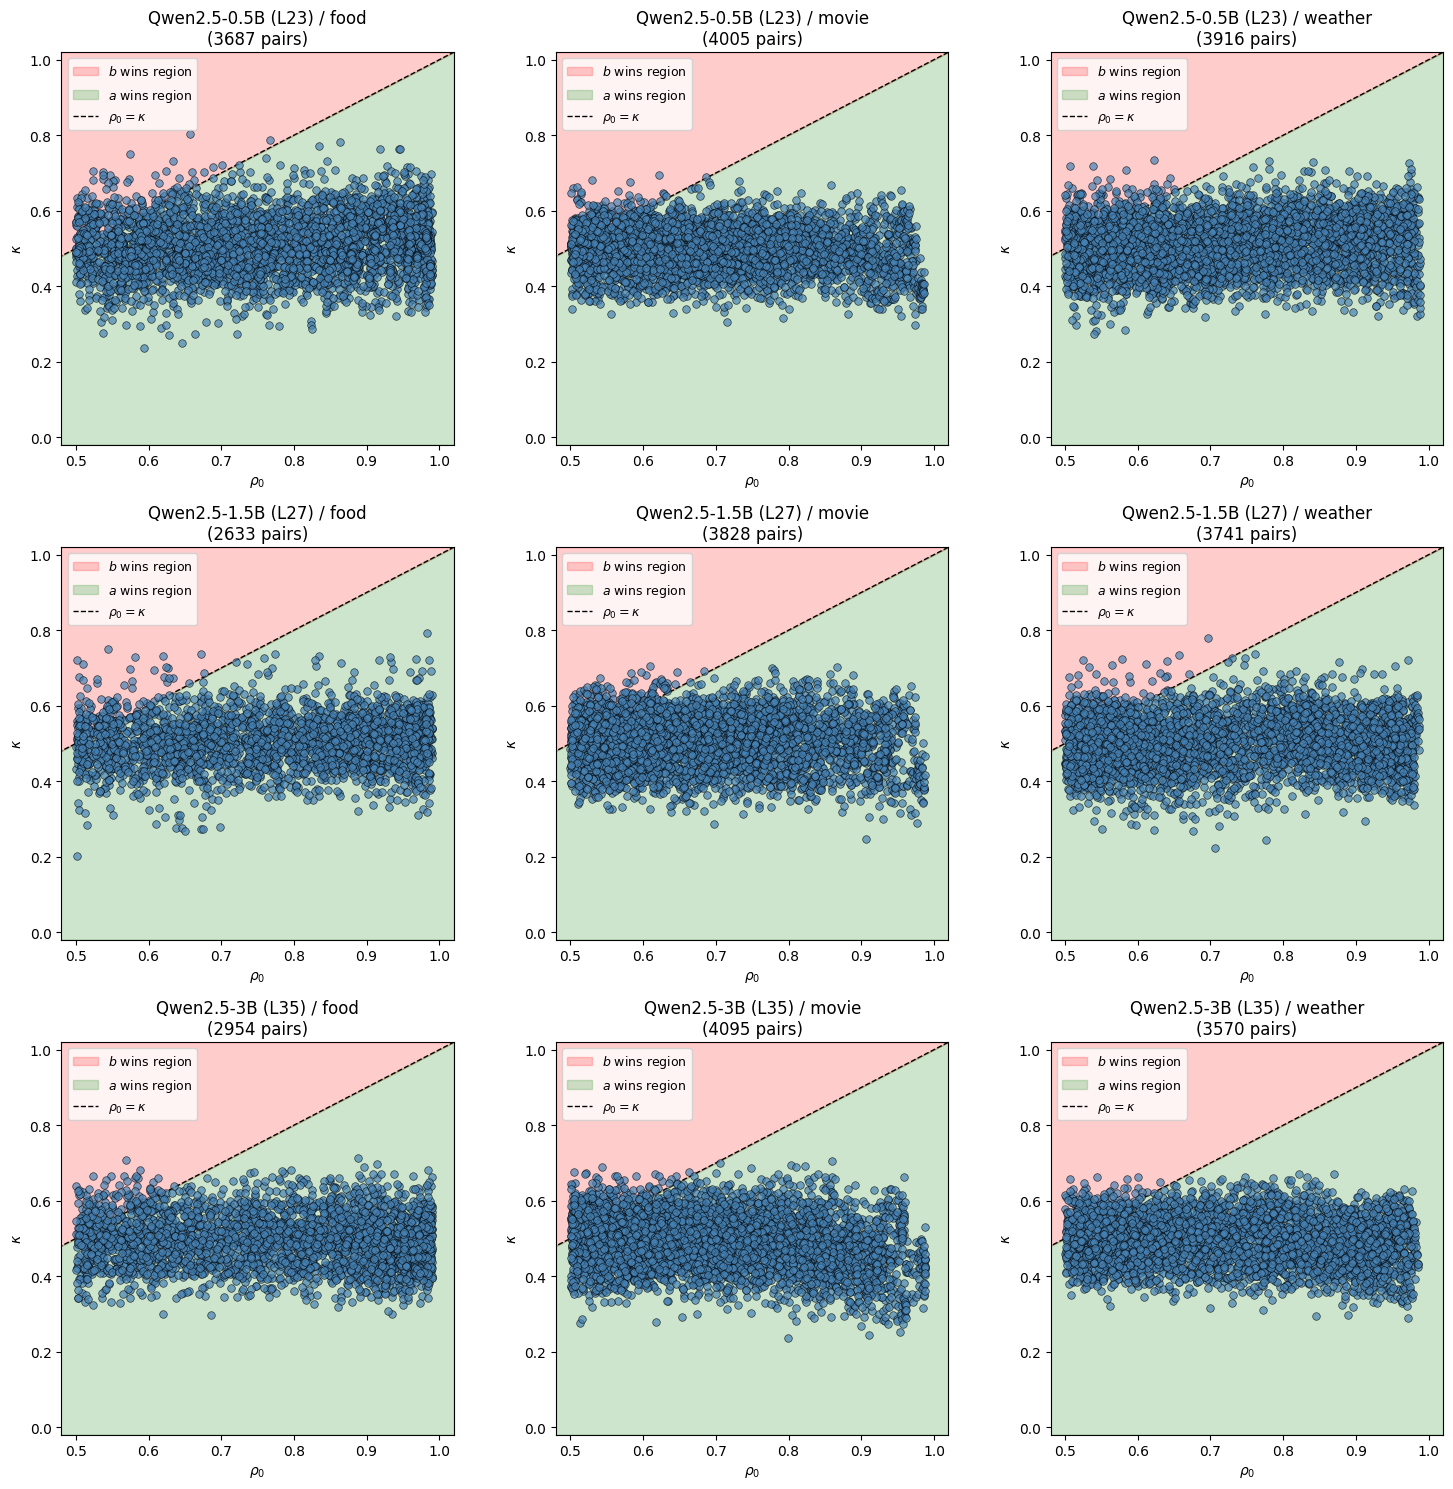

Saved to figures/rho_kappa_grid.{pdf,png}


In [3]:
import re
import matplotlib.pyplot as plt
from plots import plot_rho_kappa_scatter

# Parse grads files, deduplicate: prefer Lall over L23 for same (model, prompt)
pattern = re.compile(r"grads_(Qwen2\.5-\S+?)_(L\w+)_(\w+)_top100\.pt")
best = {}  # (model, prompt) -> (layer, path)
for f in grads_files:
    m = pattern.search(f)
    if not m:
        continue
    model_name, layer, prompt = m.group(1), m.group(2), m.group(3)
    key = (model_name, prompt)
    # prefer single-layer over Lall
    if key not in best or layer != "Lall":
        best[key] = (layer, f)

# Load pairs for each unique (model, prompt)
pair_data = {}
layer_map = {}  # (model, prompt) -> layer string
for (model_name, prompt), (layer, f) in sorted(best.items()):
    data = torch.load(f, weights_only=False)
    G, g_all = data["G"], data["g_all"]
    tokens = data["tokens"]
    token_info = data["token_info"]
    probs = torch.tensor([token_info[t]["prob"] for t in tokens])
    pairs = sweep_pairs_vectorized(tokens, probs, G, g_all,max_prob_ratio=max_prob_ratio)
    pair_data[(model_name, prompt)] = pairs
    layer_map[(model_name, prompt)] = layer
    print(f"{model_name} / {prompt} ({layer}): {len(tokens)} tokens, {len(pairs)} pairs")

# Plot grid
keys = sorted(pair_data.keys())
models = sorted(set(k[0] for k in keys))
prompts = sorted(set(k[1] for k in keys))

fig, axes = plt.subplots(len(models), len(prompts), figsize=(5*len(prompts), 5*len(models)),
                          squeeze=False)
for i, model_name in enumerate(models):
    for j, prompt in enumerate(prompts):
        ax = axes[i, j]
        key = (model_name, prompt)
        if key in pair_data:
            plot_rho_kappa_scatter(pair_data[key], ax=ax,
                                   title=f"{model_name} ({layer_map[key]}) / {prompt}\n({len(pair_data[key])} pairs)", half_range=True)
        else:
            ax.set_title(f"{model_name} / {prompt}\n(no data)")
            ax.set_visible(False)

fig.tight_layout()
fig.savefig("figures/rho_kappa_grid.pdf", bbox_inches="tight")
fig.savefig("figures/rho_kappa_grid.png", bbox_inches="tight", dpi=200)
plt.show()
print("Saved to figures/rho_kappa_grid.{pdf,png}")

In [ ]:
import os

renamed = 0
for f in sorted(glob.glob("results/validation_*.pt")):
    if "_dist_" in f:
        continue  # already tagged
    cfg = torch.load(f, weights_only=False)["config"]
    if cfg.get("pair_selection") != "dist":
        continue
    # Insert _dist before the timestamp
    p = Path(f)
    parts = p.stem.rsplit("_", 1)  # ['validation_..._T200', '1776754444']
    new_name = f"{parts[0]}_dist_{parts[1]}.pt"
    new_path = p.parent / new_name
    os.rename(f, new_path)
    renamed += 1
    print(f"  {p.name} -> {new_name}")

print(f"\nRenamed {renamed} file(s)")


Renamed 0 file(s)


Qwen2.5-0.5B L23 / food: 100 pairs, 96/100 correct (96.0%)
Qwen2.5-0.5B L23 / movie: 100 pairs, 95/100 correct (95.0%)
Qwen2.5-0.5B L23 / weather: 98 pairs, 97/98 correct (99.0%)
Qwen2.5-1.5B L27 / food: 100 pairs, 98/100 correct (98.0%)
Qwen2.5-1.5B L27 / movie: 100 pairs, 99/100 correct (99.0%)
Qwen2.5-1.5B L27 / weather: 100 pairs, 98/100 correct (98.0%)
Qwen2.5-3B L35 / food: 100 pairs, 98/100 correct (98.0%)
Qwen2.5-3B L35 / movie: 95 pairs, 94/95 correct (98.9%)
Qwen2.5-3B L35 / weather: 100 pairs, 99/100 correct (99.0%)

--- Config (shared across runs) ---
  optimizer: sgd
  lr: 0.001
  n_steps: 200
  rho_thresh: 0.95
  max_prob_ratio: 100.0
  top_k: 100
  pair_selection: dist
  n_bins: 10
  boundary_thresh: 0.0
  layer_id: [23]


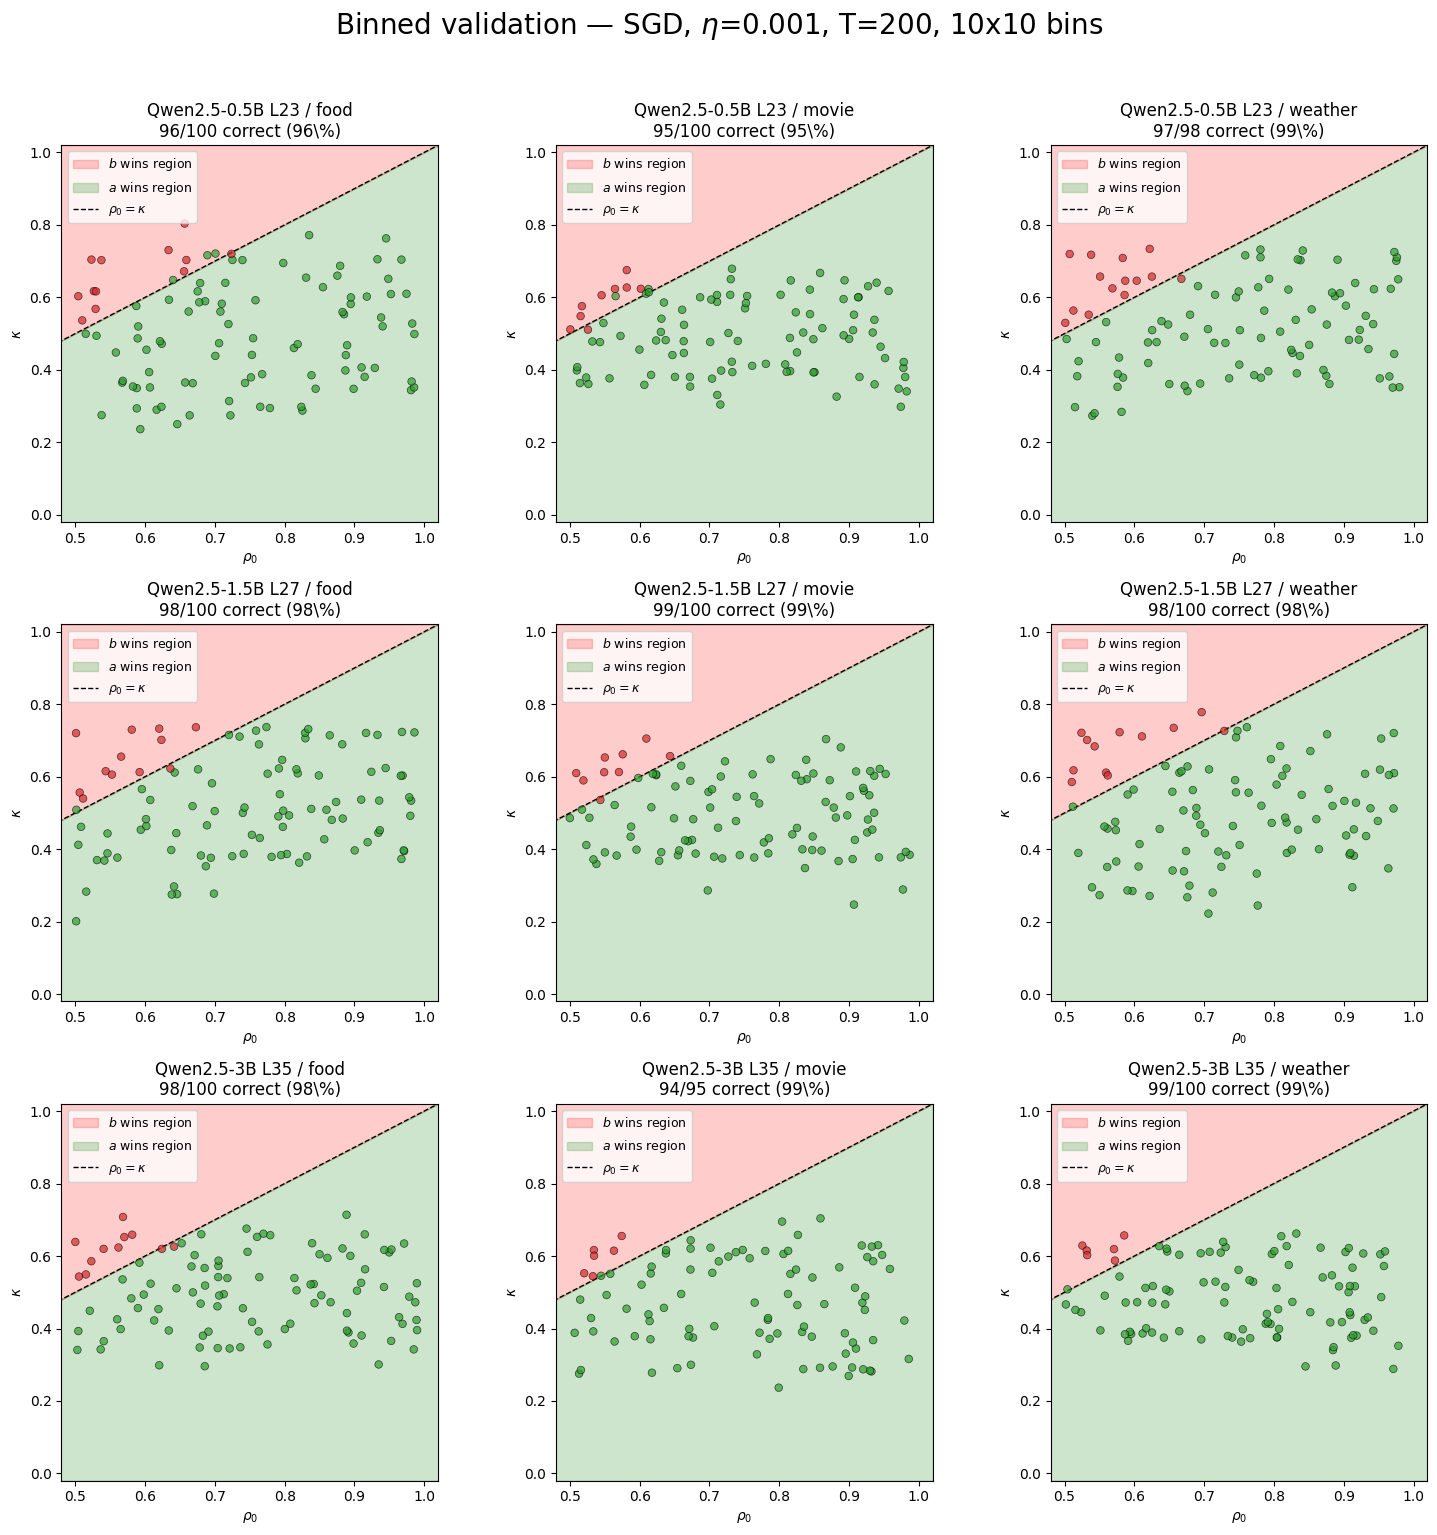

Saved to figures/rho_kappa_stratified_grid.{pdf,png}


In [6]:
# Load stratified validation results
from importlib import reload
import plots; reload(plots)
from plots import plot_rho_kappa_scatter

strat_val_files = sorted(glob.glob("results/validation_*_dist_*.pt"))
strat_results = {}  # (model_label, prompt) -> pairs list

for f in strat_val_files:
    res = torch.load(f, weights_only=False)
    cfg = res["config"]
    model_short = cfg["model"].split("/")[-1]
    layer_id = cfg.get("layer_id", "?")
    if isinstance(layer_id, list):
        layer_str = "L" + "+".join(str(l) for l in layer_id)
    else:
        layer_str = f"L{layer_id}"
    model_label = f"{model_short} {layer_str}"
    prompt = cfg["prompt_name"]
    pairs = res["pairs"]
    n_correct = sum(p["correct"] for p in pairs)
    strat_results[(model_label, prompt)] = pairs
    print(f"{model_label} / {prompt}: {len(pairs)} pairs, "
          f"{n_correct}/{len(pairs)} correct ({100*n_correct/len(pairs):.1f}%)")

# Print shared config for reproducibility (take from first file)
sample_cfg = torch.load(strat_val_files[0], weights_only=False)["config"]
print("\n--- Config (shared across runs) ---")
for k in ["optimizer", "lr", "n_steps", "rho_thresh", "max_prob_ratio",
           "top_k", "pair_selection", "n_bins", "boundary_thresh", "layer_id"]:
    if k in sample_cfg:
        print(f"  {k}: {sample_cfg[k]}")

# 3x3 grid: models x prompts
all_models = sorted(set(k[0] for k in strat_results))
all_prompts = ["food", "movie", "weather"]

fig, axes = plt.subplots(len(all_models), len(all_prompts),
                          figsize=(5*len(all_prompts), 5*len(all_models)),
                          squeeze=False)
for i, mdl in enumerate(all_models):
    for j, prm in enumerate(all_prompts):
        ax = axes[i, j]
        key = (mdl, prm)
        if key in strat_results:
            pairs = strat_results[key]
            n_ok = sum(p["correct"] for p in pairs)
            plot_rho_kappa_scatter(pairs, ax=ax, color_by_truth=True, half_range=True,
                                   title=f"{mdl} / {prm}\n{n_ok}/{len(pairs)} correct ({100*n_ok/len(pairs):.0f}\\%)")
        else:
            ax.set_title(f"{mdl} / {prm}\n(no data)")
            ax.set_visible(False)

cfg_str = (f"SGD, $\\eta$={sample_cfg['lr']}, T={sample_cfg['n_steps']}, 10x10 bins")
fig.suptitle(f"Binned validation — {cfg_str}", fontsize=20, y=1.02)
fig.tight_layout()
fig.savefig("figures/rho_kappa_stratified_grid.pdf", bbox_inches="tight")
fig.savefig("figures/rho_kappa_stratified_grid.png", bbox_inches="tight", dpi=200)
plt.show()
print("Saved to figures/rho_kappa_stratified_grid.{pdf,png}")

Validation files: 87 raw -> 87 deduplicated


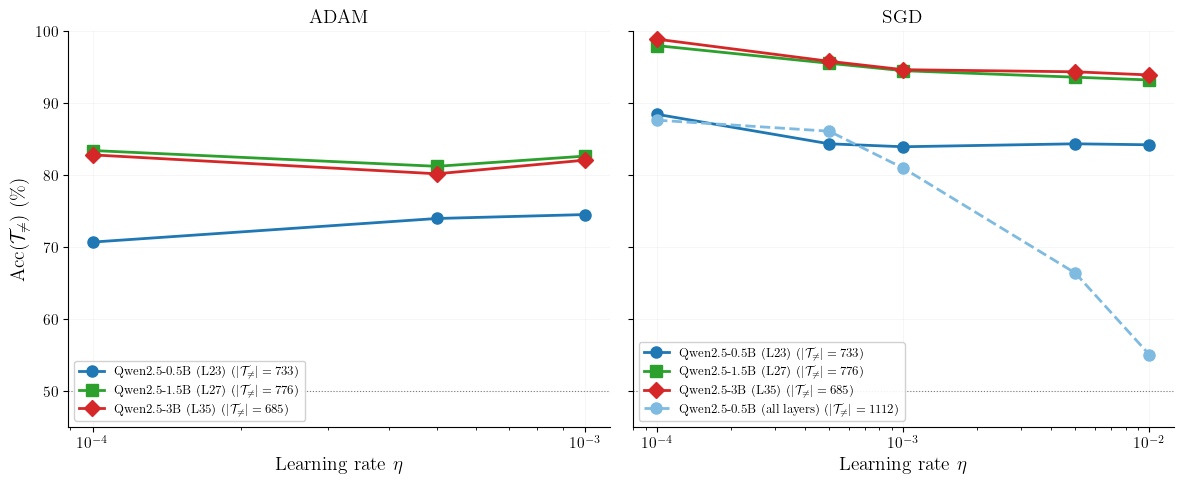

Saved to figures/lr_vs_acc_interesting.{pdf,png}


In [ ]:
# LR vs accuracy on interesting pairs
# Panels: SGD / Adam.  Lines: model sizes.  Full-model = distinct color.
from collections import defaultdict
import matplotlib
matplotlib.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 9,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

int_val_files_raw = [f for f in sorted(glob.glob("results/validation_*.pt"))
                     if "_dist_" not in f]

# Deduplicate: keep latest file per (model, layer_id, prompt, optimizer,lr )
_dedup = {}
_dupes = []
for f in int_val_files_raw:
    res_tmp = torch.load(f, weights_only=False)
    cfg_tmp = res_tmp["config"]
    key = (cfg_tmp["model"], str(cfg_tmp.get("layer_id")),
           cfg_tmp["prompt_name"], cfg_tmp["optimizer"], cfg_tmp["lr"])
    if key in _dedup:
        _dupes.append((_dedup[key], f))
    _dedup[key] = f  # sorted ascending by timestamp, so last wins
int_val_files = list(_dedup.values())
print(f"Validation files: {len(int_val_files_raw)} raw -> {len(int_val_files)} deduplicated")
if _dupes:
    print(f"\nDuplicate runs ({len(_dupes)}):")
    for old, new in _dupes:
        print(f"  {Path(old).name}  ->  {Path(new).name}")

# Classify each run: (model_size, frozen_or_full, optimizer, lr)
acc_by = defaultdict(list)

for f in int_val_files:
    res = torch.load(f, weights_only=False)
    cfg = res["config"]
    model_short = cfg["model"].split("/")[-1]
    layer_id = cfg.get("layer_id", None)
    # Determine if frozen-block or full-model
    if layer_id is None or (isinstance(layer_id, list) and len(layer_id) > 1):
        mode = "full"
        layer_tag = "all layers"
    else:
        mode = "frozen"
        lid = layer_id[0] if isinstance(layer_id, list) else layer_id
        layer_tag = f"L{lid}"
    label = f"{model_short} ({layer_tag})"
    opt = cfg["optimizer"]
    lr = cfg["lr"]
    pairs = res["pairs"]
    # Filter to interesting pairs: κ predicts reversal of initial majority
    pairs = [p for p in pairs
             if (p["rho"] > 0.5 and p["kappa"] > p["rho"]) or
                (p["rho"] < 0.5 and p["kappa"] < p["rho"])]
    n_correct = sum(p["correct"] for p in pairs)
    acc_by[(label, model_short, mode, opt, lr)].append((n_correct, len(pairs)))

# Pool over prompts: (label, model_short, mode, opt) -> [(lr, acc, n)]
plot_data = defaultdict(list)
for (label, model_short, mode, opt, lr), counts in acc_by.items():
    total_correct = sum(c for c, _ in counts)
    total_pairs = sum(n for _, n in counts)
    acc = total_correct / total_pairs
    plot_data[(label, model_short, mode, opt)].append((lr, acc, total_pairs))

for key in plot_data:
    plot_data[key].sort()

# Colors: frozen = solid hue, full = lighter/different hue
MODEL_COLOR_FROZEN = {
    "Qwen2.5-0.5B": "#1f77b4",
    "Qwen2.5-1.5B": "#2ca02c",
    "Qwen2.5-3B":   "#d62728",
}
MODEL_COLOR_FULL = {
    "Qwen2.5-0.5B": "#7fbbe0",
    "Qwen2.5-1.5B": "#7fdb7f",
    "Qwen2.5-3B":   "#e88a8a",
}
MODEL_MARKER = {
    "Qwen2.5-0.5B": "o",
    "Qwen2.5-1.5B": "s",
    "Qwen2.5-3B":   "D",
}

# Determine which optimizers have data
optimizers = sorted(set(k[3] for k in plot_data))
n_panels = len(optimizers)

fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5), sharey=True, squeeze=False)
axes = axes[0]

for idx, opt in enumerate(optimizers):
    ax = axes[idx]
    lines_in_panel = [(k, v) for k, v in plot_data.items() if k[3] == opt]
    # Sort: frozen first, then full; within each, by model size
    lines_in_panel.sort(key=lambda x: (x[0][2], x[0][1]))

    for (label, model_short, mode, _), entries in lines_in_panel:
        lrs = [e[0] for e in entries]
        accs = [100 * e[1] for e in entries]
        n_per_point = entries[0][2]  # same for all lr values
        colors = MODEL_COLOR_FROZEN if mode == "frozen" else MODEL_COLOR_FULL
        color = colors.get(model_short, "gray")
        marker = MODEL_MARKER.get(model_short, "x")
        ls = "-" if mode == "frozen" else "--"
        ax.plot(lrs, accs, ls=ls, marker=marker, color=color, lw=2, ms=8,
                label=f"{label} ($|\\mathcal{{T}}_{{\\neq}}|={n_per_point}$)", zorder=3)

    ax.set_xscale("log")
    ax.set_xlabel(r"Learning rate $\eta$")
    if idx == 0:
        ax.set_ylabel(r"$\mathrm{Acc}(\mathcal{T}_{\neq})$ (\%)")
    ax.set_ylim(45, 100)
    ax.axhline(50, color="k", ls=":", lw=0.8, alpha=0.5)
    ax.legend(framealpha=0.9, edgecolor="0.8", loc="lower left")
    ax.grid(True, alpha=0.15, lw=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_title(opt.upper())

fig.tight_layout()
fig.savefig("figures/lr_vs_acc_interesting.pdf", bbox_inches="tight")
fig.savefig("figures/lr_vs_acc_interesting.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved to figures/lr_vs_acc_interesting.{pdf,png}")

87 run points


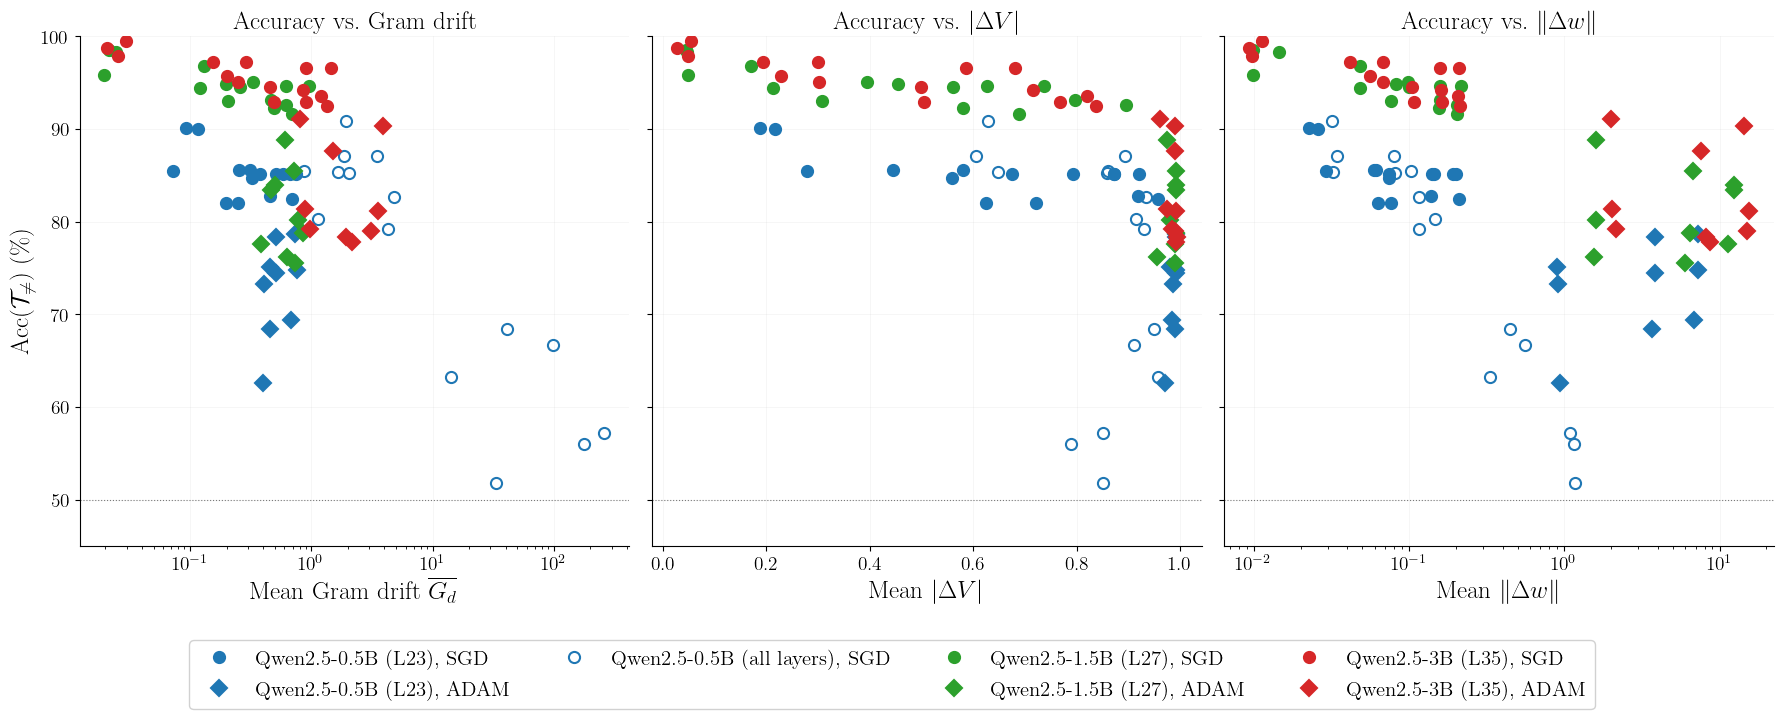

Saved to figures/acc_vs_drift_panels.{pdf,png}


In [8]:
# Accuracy vs mean Gram drift / ΔV / Δw (per-run scatter, 3 panels)
import numpy as np

# Reuse deduplicated int_val_files from previous cell
run_points = []  # list of dicts

for f in int_val_files:
    res = torch.load(f, weights_only=False)
    cfg = res["config"]
    model_short = cfg["model"].split("/")[-1]
    layer_id = cfg.get("layer_id", None)
    if layer_id is None or (isinstance(layer_id, list) and len(layer_id) > 1):
        mode = "full"
        layer_tag = "all layers"
    else:
        mode = "frozen"
        lid = layer_id[0] if isinstance(layer_id, list) else layer_id
        layer_tag = f"L{lid}"
    opt = cfg["optimizer"]
    lr = cfg["lr"]
    prompt = cfg["prompt_name"]
    pairs = res["pairs"]
    # Filter to interesting pairs
    pairs = [p for p in pairs
             if (p["rho"] > 0.5 and p["kappa"] > p["rho"]) or
                (p["rho"] < 0.5 and p["kappa"] < p["rho"])]
    if len(pairs) == 0:
        continue
    n_correct = sum(p["correct"] for p in pairs)
    acc = n_correct / len(pairs)
    mean_gd = np.mean([p["gram_drift"] for p in pairs])
    mean_pd = np.mean([p["param_delta"] for p in pairs])
    # ΔV = |total_mass_final - total_mass_0|  (change in π(a)+π(b))
    mean_dv = np.mean([abs(p["total_mass"][-1] - p["total_mass"][0]) for p in pairs])
    run_points.append(dict(
        mean_gd=mean_gd, mean_pd=mean_pd, mean_dv=mean_dv,
        acc=acc, model_short=model_short, mode=mode,
        layer_tag=layer_tag, opt=opt, lr=lr, prompt=prompt))

print(f"{len(run_points)} run points")

# Plot
MODEL_COLORS = {
    "Qwen2.5-0.5B": "#1f77b4",
    "Qwen2.5-1.5B": "#2ca02c",
    "Qwen2.5-3B":   "#d62728",
}
OPT_MARKER = {"sgd": "o", "adam": "D"}
MODE_FILL = {"frozen": "full", "full": "none"}  # filled vs hollow

panels = [
    ("mean_gd", r"Mean Gram drift $\overline{G_d}$", r"Accuracy vs.\ Gram drift", True),
    ("mean_dv", r"Mean $|\Delta V|$", r"Accuracy vs.\ $|\Delta V|$", False),
    ("mean_pd", r"Mean $\|\Delta w\|$", r"Accuracy vs.\ $\|\Delta w\|$", True),
]

FS_LABEL = 18
FS_TITLE = 18
FS_TICK = 14
FS_LEGEND = 15

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

for ax, (xkey, xlabel, title, use_log) in zip(axes, panels):
    legend_handles = {}
    for pt in run_points:
        color = MODEL_COLORS.get(pt["model_short"], "gray")
        marker = OPT_MARKER.get(pt["opt"], "x")
        fillstyle = MODE_FILL.get(pt["mode"], "full")
        label = f"{pt['model_short']} ({pt['layer_tag']}), {pt['opt'].upper()}"
        h = ax.plot(pt[xkey], 100 * pt["acc"], marker=marker, color=color,
                    ms=8, lw=0, fillstyle=fillstyle, markeredgewidth=1.5,
                    markeredgecolor=color, zorder=3)
        if label not in legend_handles:
            legend_handles[label] = h[0]

    if use_log:
        ax.set_xscale("log")
    ax.set_xlabel(xlabel, fontsize=FS_LABEL)
    ax.set_ylim(45, 100)
    ax.axhline(50, color="k", ls=":", lw=0.8, alpha=0.5)
    ax.grid(True, alpha=0.15, lw=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_title(title, fontsize=FS_TITLE)
    ax.tick_params(axis="both", labelsize=FS_TICK)

axes[0].set_ylabel(r"$\mathrm{Acc}(\mathcal{T}_{\neq})$ (\%)", fontsize=FS_LABEL)

# Shared legend below all panels: SGD on top row, Adam on bottom row.
# matplotlib fills legend row-major, so we list ALL SGD entries first
# (one per column), then ALL Adam entries.
unique_keys = set()  # (model_short, mode, opt)
for pt in run_points:
    unique_keys.add((pt["model_short"], pt["mode"], pt["opt"]))
col_keys = sorted({(m, mode) for m, mode, _ in unique_keys},
                  key=lambda x: (x[0], x[1]))  # by model, then mode

def _find_label(model, mode, opt):
    for lab in legend_handles:
        if not lab.endswith(f", {opt.upper()}"):
            continue
        if not lab.startswith(f"{model} ("):
            continue
        is_full = "(all layers)" in lab
        if (mode == "full") == is_full:
            return lab
    return None

from matplotlib.lines import Line2D
_blank = Line2D([], [], linestyle="", marker="")

# Build row-major: interleave [SGD, Adam] per column (previous ordering)
handles, labels = [], []
for m, mode in col_keys:
    for opt in ["sgd", "adam"]:
        lab = _find_label(m, mode, opt)
        if lab is None:
            handles.append(_blank)
            labels.append("")
        else:
            handles.append(legend_handles[lab])
            labels.append(lab)

n_cols = len(col_keys)
fig.legend(handles, labels,
           loc="lower center", bbox_to_anchor=(0.5, -0.04),
           ncol=n_cols,
           framealpha=0.9, edgecolor="0.8", fontsize=FS_LEGEND)

fig.tight_layout(rect=[0, 0.10, 1, 1])
fig.savefig("figures/acc_vs_drift_panels.pdf", bbox_inches="tight")
fig.savefig("figures/acc_vs_drift_panels.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved to figures/acc_vs_drift_panels.{pdf,png}")

Qwen2.5-1.5B (L27), SGD, lr=0.0001: 2557 pairs from ['food', 'movie', 'weather']
Qwen2.5-0.5B (all layers), SGD, lr=0.01: 2970 pairs from ['food', 'movie', 'weather']


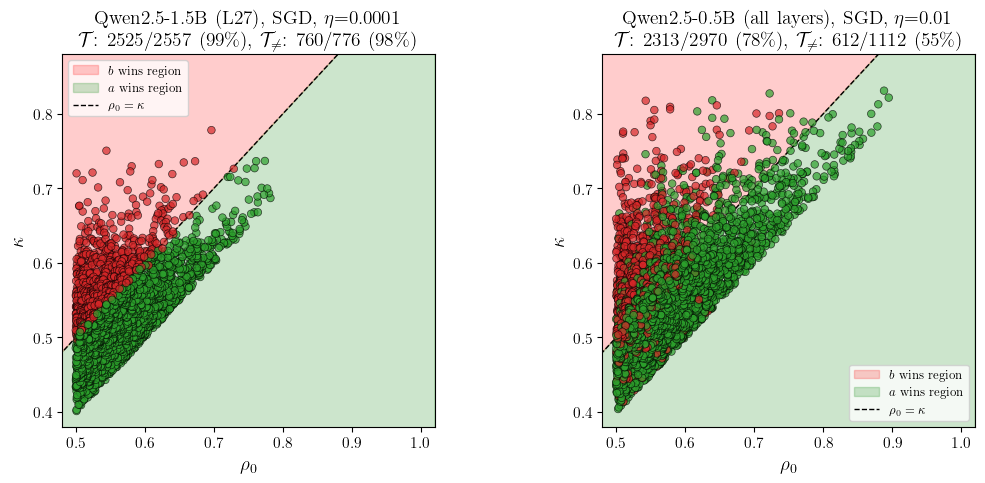

Saved to figures/good_vs_bad_case.{pdf,png}


In [9]:
# Side-by-side: good vs bad case (all prompts accumulated)
from importlib import reload
import plots; reload(plots)
from plots import plot_rho_kappa_scatter

# Define cases by (model, layer_id_str, optimizer, lr)
cases = [
    (("Qwen/Qwen2.5-1.5B", "[27]", "sgd", 0.0001), "Qwen2.5-1.5B (L27)", "works well"),
    (("Qwen/Qwen2.5-0.5B", "None", "sgd", 0.01),   "Qwen2.5-0.5B (all layers)", "fails"),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, (match_key, label, case_label) in zip(axes, cases):
    target_model, target_lid, target_opt, target_lr = match_key
    # Collect pairs from all prompts matching this config
    all_pairs = []
    prompts_found = []
    for f in int_val_files:
        res = torch.load(f, weights_only=False)
        cfg = res["config"]
        if (cfg["model"] == target_model and
            str(cfg.get("layer_id")) == target_lid and
            cfg["optimizer"] == target_opt and
            cfg["lr"] == target_lr):
            all_pairs.extend(res["pairs"])
            prompts_found.append(cfg["prompt_name"])

    print(f"{label}, {target_opt.upper()}, lr={target_lr}: "
          f"{len(all_pairs)} pairs from {sorted(set(prompts_found))}")

    # Accuracy on all pairs (T)
    n_all = len(all_pairs)
    n_ok_all = sum(p["correct"] for p in all_pairs)
    acc_all = 100 * n_ok_all / n_all if n_all > 0 else 0

    # Accuracy on interesting pairs (T_≠)
    interesting = [p for p in all_pairs
                   if (p["rho"] > 0.5 and p["kappa"] > p["rho"]) or
                      (p["rho"] < 0.5 and p["kappa"] < p["rho"])]
    n_int = len(interesting)
    n_ok_int = sum(p["correct"] for p in interesting)
    acc_int = 100 * n_ok_int / n_int if n_int > 0 else 0

    title = (f"{label}, {target_opt.upper()}, $\\eta$={target_lr}\n"
             f"$\\mathcal{{T}}$: {n_ok_all}/{n_all} ({acc_all:.0f}\\%),  "
             f"$\\mathcal{{T}}_{{\\neq}}$: {n_ok_int}/{n_int} ({acc_int:.0f}\\%)")
    plot_rho_kappa_scatter(all_pairs, ax=ax, color_by_truth=True,
                           half_range=True, title=title)
    ax.set_ylim(0.38, 0.88)

fig.tight_layout()
fig.savefig("figures/good_vs_bad_case.pdf", bbox_inches="tight")
fig.savefig("figures/good_vs_bad_case.png", bbox_inches="tight", dpi=300)
plt.show()
print("Saved to figures/good_vs_bad_case.{pdf,png}")

In [11]:
# Summary table: all configs from results-gpu2, accumulated across prompts
import pandas as pd
import numpy as np

# --- Load and deduplicate all non-stratified validation pairs ---
val_files = sorted(glob.glob("results/validation_*.pt"))
val_files = [f for f in val_files if "_dist_" not in f]

pair_dict = {}  # keyed by (model, layer_id_str, prompt, opt, lr, a, b)
for f in val_files:
    ts = int(Path(f).stem.rsplit("_", 1)[-1])
    res = torch.load(f, weights_only=False)
    cfg = res["config"]
    model = cfg["model"].split("/")[-1]
    layer_id = cfg.get("layer_id")
    if layer_id is None or (isinstance(layer_id, list) and len(layer_id) > 1):
        layer_str = "all"
    else:
        lid = layer_id[0] if isinstance(layer_id, list) else layer_id
        layer_str = f"L{lid}"
    opt = cfg["optimizer"]
    lr = cfg["lr"]
    prompt = cfg["prompt_name"]
    for p in res["pairs"]:
        log = p["log"]
        mass_0 = log["a_mass"][0] + log["b_mass"][0]
        mass_f = log["a_mass"][-1] + log["b_mass"][-1]
        key = (model, layer_str, prompt, opt, lr, p["a"].strip(), p["b"].strip())
        row = dict(
            model=model, layer=layer_str, prompt=prompt,
            optimizer=opt, lr=lr,
            a=p["a"].strip(), b=p["b"].strip(),
            rho=p["rho"], kappa=p["kappa"], rho_final=p["rho_final"],
            pred=p["pred"], actual=p["actual"], correct=p["correct"],
            gram_drift=p["gram_drift"], param_delta=p["param_delta"],
            n_steps=len(log["step"]),
            mass_0=mass_0, mass_f=mass_f, delta_v=mass_f - mass_0,
        )
        if key not in pair_dict or ts > pair_dict[key][0]:
            pair_dict[key] = (ts, row)

df = pd.DataFrame([v[1] for v in pair_dict.values()])
print(f"Loaded {len(df)} unique pairs from {len(val_files)} files")

# Derived columns
df["abs_delta_rho"] = (df["rho_final"] - df["rho"]).abs()
df["margin"] = (df["kappa"] - df["rho"]).abs()
df["is_reversal"] = ((df["rho"] > 0.5) & (df["kappa"] > df["rho"])) | \
                    ((df["rho"] < 0.5) & (df["kappa"] < df["rho"]))
df["collapsed"] = (df["rho_final"] > 0.95) | (df["rho_final"] < 0.05)

# --- Aggregate across prompts ---
agg_cols = ["model", "layer", "optimizer", "lr"]

def summarize(g):
    rev = g[g["is_reversal"]]
    bnd = g[~g["is_reversal"]]
    return pd.Series({
        "prompts": ", ".join(sorted(g["prompt"].unique())),
        "N": len(g),
        "N_rev": len(rev),
        "N_bnd": len(bnd),
        "acc": g["correct"].mean(),
        "acc_rev": rev["correct"].mean() if len(rev) > 0 else np.nan,
        "acc_bnd": bnd["correct"].mean() if len(bnd) > 0 else np.nan,
        "collapsed_pct": g["collapsed"].mean(),
        "mean_|Δρ|": g["abs_delta_rho"].mean(),
        "mean_ΔV": g["delta_v"].abs().mean(),
        "mean_G_d": g["gram_drift"].mean(),
        "mean_‖Δw‖": g["param_delta"].mean(),
        "mean_margin": g["margin"].mean(),
    })

table = df.groupby(agg_cols).apply(summarize, include_groups=False).reset_index()

# Sort: model size, layer, optimizer, lr
model_order = {"Qwen2.5-0.5B": 0, "Qwen2.5-1.5B": 1, "Qwen2.5-3B": 2}
table["_sort"] = table["model"].map(model_order).fillna(99)
table = table.sort_values(["_sort", "layer", "optimizer", "lr"]).drop(columns="_sort").reset_index(drop=True)

# Format for display
fmt = {
    "acc": "{:.1%}".format, "acc_rev": "{:.1%}".format, "acc_bnd": "{:.1%}".format,
    "collapsed_pct": "{:.1%}".format,
    "mean_|Δρ|": "{:.3f}".format, "mean_ΔV": "{:.4f}".format,
    "mean_G_d": "{:.4f}".format, "mean_‖Δw‖": "{:.2f}".format,
    "mean_margin": "{:.3f}".format, "lr": "{:.0e}".format,
}
display(table.style.format(fmt, na_rep="—").set_caption(
    f"Validation summary — results-gpu2 ({len(df)} pairs, {len(val_files)} files)"))

# --- Save as LaTeX table ---
def fmt_pct(x):
    return f"{100*x:.1f}" if not np.isnan(x) else "---"

def fmt_lr(lr):
    exp = int(np.floor(np.log10(lr)))
    coeff = lr / 10**exp
    if abs(coeff - 1.0) < 1e-9:
        return f"$10^{{{exp}}}$"
    return f"${coeff:g} \\cdot 10^{{{exp}}}$"

ncols = 14
lines = []
prev_model = None; prev_layer = None; prev_opt = None
for _, r in table.iterrows():
    model_layer_key = (r["model"], r["layer"])
    model_layer_rows = len(table[(table["model"] == r["model"]) & (table["layer"] == r["layer"])])
    if model_layer_key != (prev_model, prev_layer):
        if prev_model is not None:
            lines.append(r"\midrule")
        layer_suffix = "" if r["layer"] == "all" else f"\\\\\\scriptsize {r['layer']}"
        model_cell = f"\\multirow{{{model_layer_rows}}}{{*}}{{\\shortstack{{{r['model']}{layer_suffix}}}}}"
        prev_model, prev_layer = r["model"], r["layer"]
        prev_opt = None
    else:
        model_cell = ""
    if r["optimizer"] != prev_opt:
        if prev_opt is not None:
            lines.append(f"\\cmidrule(lr){{2-{ncols}}}")
        prev_opt = r["optimizer"]

    row_vals = [
        model_cell,
        r["optimizer"].upper(),
        fmt_lr(r["lr"]),
        str(int(r["N"])),
        str(int(r["N_rev"])),
        str(int(r["N_bnd"])),
        fmt_pct(r["acc"]),
        f"\\textbf{{{fmt_pct(r['acc_rev'])}}}",
        fmt_pct(r["acc_bnd"]),
        fmt_pct(r["collapsed_pct"]),
        f"{r['mean_ΔV']:.3f}",
        f"{r['mean_G_d']:.4f}",
        f"{r['mean_|Δρ|']:.3f}",
        f"{r['mean_margin']:.3f}",
    ]
    lines.append(" & ".join(row_vals) + r" \\")

body = "\n".join(lines)

latex_out = (
    r"\begin{landscape}" "\n"
    r"\begin{table}[p]" "\n"
    r"\centering" "\n"
    r"\caption{$\kappa$-prediction accuracy aggregated across prompts (results-gpu2)." "\n"
    r"         Accuracies and collapse rate are percentages.}" "\n"
    r"\label{tab:gpu2-results}" "\n"
    r"\small" "\n"
    r"\begin{tabular}{lll|rrr|cccc|rrrr}" "\n"
    r"\toprule" "\n"
    r"Model & Opt & $\eta$ & $|\mathcal{T}|$ & $|\mathcal{T}_{\neq}|$ & $|\mathcal{T} \setminus \mathcal{T}_{\neq}|$"
    r" & $\text{Acc}(\mathcal{T})$ & $\textbf{Acc}(\boldsymbol{\mathcal{T}_{\neq}})$ & $\text{Acc}(\mathcal{T} \setminus \mathcal{T}_{\neq})$ & $C$"
    r" & $\overline{|\Delta V|}$ & $\overline{G_d}$"
    r" & $\overline{|\Delta\rho|}$ & $\overline{|\kappa{-}\rho_0|}$ \\" "\n"
    r"\midrule" "\n"
    + body + "\n"
    r"\bottomrule" "\n"
    r"\end{tabular}" "\n"
    r"\end{table}" "\n"
    r"\end{landscape}"
)

out_path = Path("tables/results.tex")
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(latex_out)
print(f"\nLaTeX table saved to {out_path}")

Loaded 77378 unique pairs from 87 files


,model,layer,optimizer,lr,prompts,N,N_rev,N_bnd,acc,acc_rev,acc_bnd,collapsed_pct,mean_|Δρ|,mean_ΔV,mean_G_d,mean_‖Δw‖,mean_margin
0,Qwen2.5-0.5B,L23,adam,1e-04,"food, movie, weather",2782,733,2049,78.0%,70.7%,80.6%,99.3%,0.449,0.9673,0.3950,0.87,0.051
1,Qwen2.5-0.5B,L23,adam,5e-04,"food, movie, weather",2782,733,2049,82.2%,73.9%,85.1%,99.7%,0.449,0.9919,0.4911,3.61,0.051
2,Qwen2.5-0.5B,L23,adam,1e-03,"food, movie, weather",2782,733,2049,84.9%,74.5%,88.6%,99.7%,0.448,0.9897,0.7261,6.79,0.051
3,Qwen2.5-0.5B,L23,sgd,1e-04,"food, movie, weather",2782,733,2049,95.0%,88.4%,97.4%,43.1%,0.219,0.1933,0.0846,0.03,0.051
4,Qwen2.5-0.5B,L23,sgd,5e-04,"food, movie, weather",2782,733,2049,92.6%,84.3%,95.6%,98.9%,0.417,0.4341,0.2146,0.06,0.051
5,Qwen2.5-0.5B,L23,sgd,1e-03,"food, movie, weather",2782,733,2049,92.5%,83.9%,95.5%,99.6%,0.428,0.5347,0.2748,0.07,0.051
6,Qwen2.5-0.5B,L23,sgd,5e-03,"food, movie, weather",2782,733,2049,92.5%,84.3%,95.4%,99.1%,0.439,0.7881,0.5177,0.14,0.051
7,Qwen2.5-0.5B,L23,sgd,1e-02,"food, movie, weather",2782,733,2049,92.3%,84.2%,95.2%,98.6%,0.442,0.8815,0.7166,0.20,0.051
8,Qwen2.5-0.5B,all,sgd,1e-04,"food, movie, weather",2970,1112,1858,92.1%,87.6%,94.8%,99.9%,0.435,0.5801,1.7792,0.03,0.056
9,Qwen2.5-0.5B,all,sgd,5e-04,"food, movie, weather",2970,1112,1858,92.5%,86.1%,96.3%,99.4%,0.438,0.8313,2.3124,0.08,0.056



LaTeX table saved to tables/results.tex
